In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

data = load_data()
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}

# Session A : Speed Tuning

by Zhidong Zhang

## 0 Run analysis

In [2]:
mode='equal_size'

tunings = {label: SpeedTuning(trial_data_dict[stim], mode=mode) for (label, stim) in zip(SHORT_STIM, STIMULI)}
for stim in SHORT_STIM:
    tunings[stim].run()

In [3]:
# All stimuli
st_stimuli = SpeedTuning(trial_data_dict, mode=mode)
st_stimuli.run()
# Gratings
st_gratings = SpeedTuning({label: trial_data_dict[stim] for (label, stim) in zip(SHORT_STIM, STIMULI) if stim in ['drifting_gratings', 'static_gratings']}, mode=mode)
st_gratings.run()

### Glance at the distribution of speed

The distribution of running speed is highly unbalanced! -> `_subsample()` 

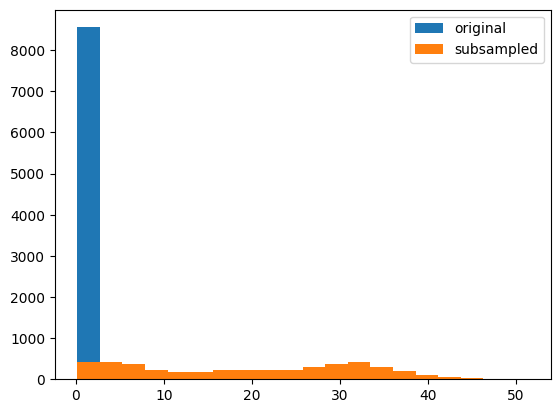

In [4]:
plt.hist(st_stimuli.speeds, bins=st_stimuli.bins_edges,label='original')
sub_speeds = st_stimuli.speeds[st_stimuli.bins_sub_ids!=-1]
plt.hist(sub_speeds, bins=st_stimuli.bins_edges,label='subsampled')
# plt.yscale('log')
plt.legend()

## 1 Tuning to different stimuli

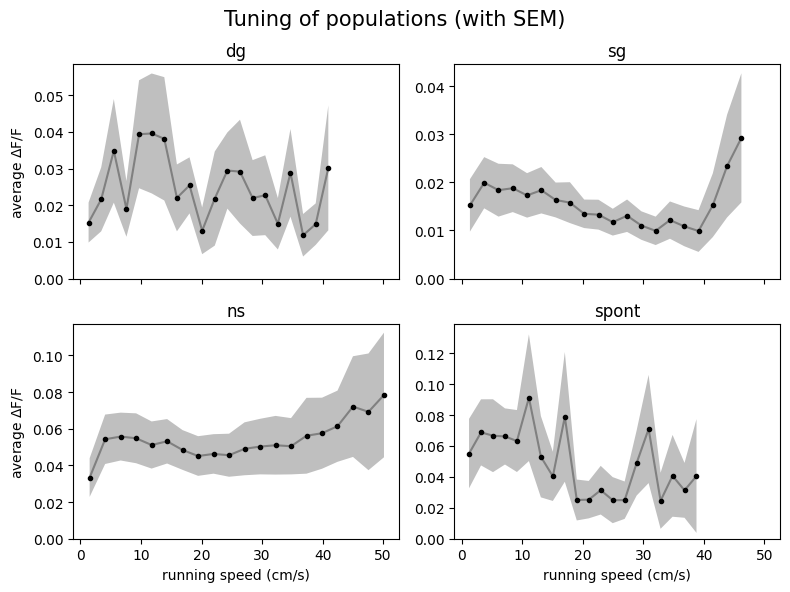

In [5]:
fig = plot_tuning_curves_grid(tunings, labels=SHORT_STIM)
plt.suptitle("Tuning of populations (with SEM)", fontsize=15)
plt.show()

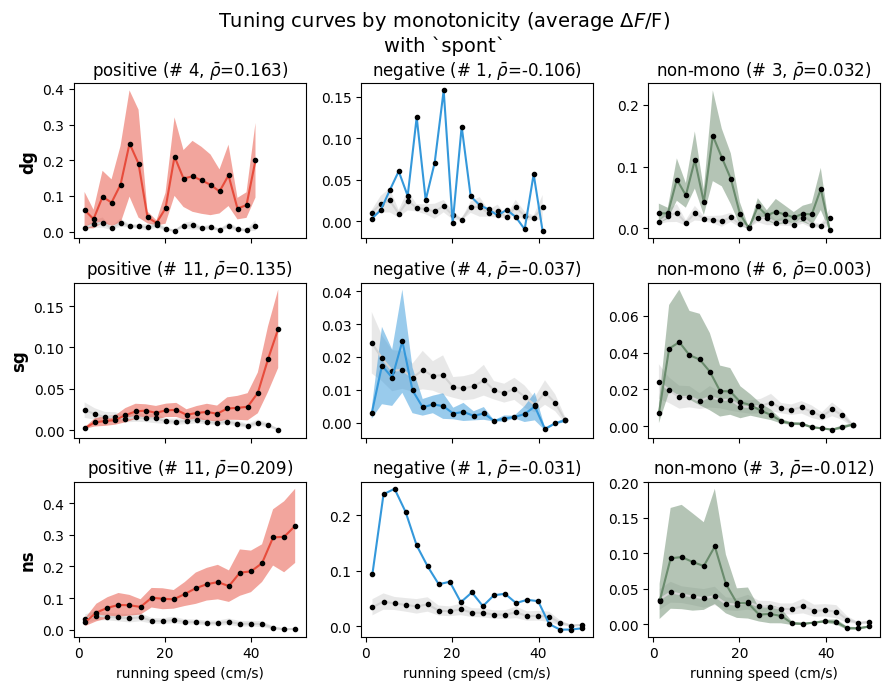

In [6]:
stim_labels = ['dg', 'sg', 'ns']
cat_titles = ['positive', 'negative', 'non-mono']

fig, axes = plt.subplots(3, 3, figsize=(9, 7), sharex='col')

for row, stim in enumerate(stim_labels):
    tunings[stim].plot_tuning_by_monotonicity(axes=axes[row])
    axes[row, 0].set_ylabel(stim, fontsize=12, fontweight='bold')
    for ax in axes[row]:
        ax.set_xlabel(None)

# # column labels (top)
# for col, title in enumerate(cat_titles):
#     axes[0, col].set_title(title, fontsize=12, fontweight='bold')

# x label only on bottom row
for col in range(3):
    axes[2, col].set_xlabel('running speed (cm/s)')

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.suptitle('Tuning curves by monotonicity (average $\\Delta F$/F) \n''with `spont`', fontsize=14)

plt.savefig('doc/figures/tuning_by_monotonicity.png')
plt.show()

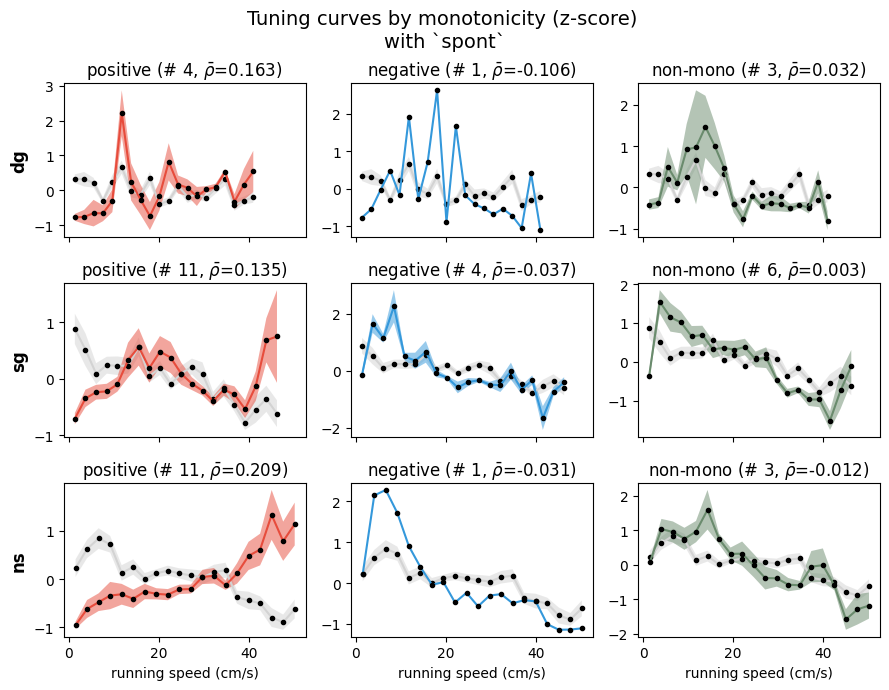

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(9, 7), sharex='col')

for row, stim in enumerate(stim_labels):
    tunings[stim].plot_tuning_by_monotonicity_zscore(axes=axes[row])
    axes[row, 0].set_ylabel(stim, fontsize=12, fontweight='bold')
    for ax in axes[row]:
        ax.set_xlabel(None)

# # column labels (top)
# for col, title in enumerate(cat_titles):
#     axes[0, col].set_title(title, fontsize=12, fontweight='bold')

# x label only on bottom row
for col in range(3):
    axes[2, col].set_xlabel('running speed (cm/s)')

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.suptitle('Tuning curves by monotonicity (z-score) \n''with `spont`', fontsize=14)

plt.savefig('doc/figures/tuning_by_monotonicity_zscore.png')
plt.show()

## 2 Number of tuned neurons, with their $\rho$

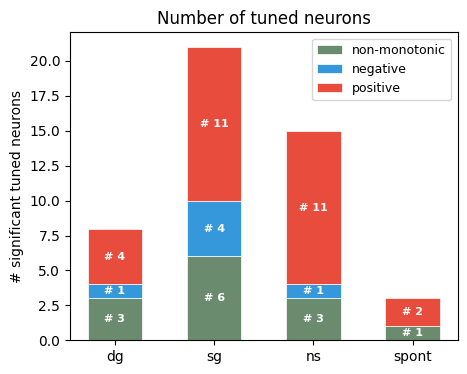

In [8]:
ax = plot_monotonicity_stacked_bar(tunings, figsize=(5,4))
ax.set_title("Number of tuned neurons")
plt.savefig('doc/figures/tuned_neurons_numbers.png')
plt.show()

(47, 3)


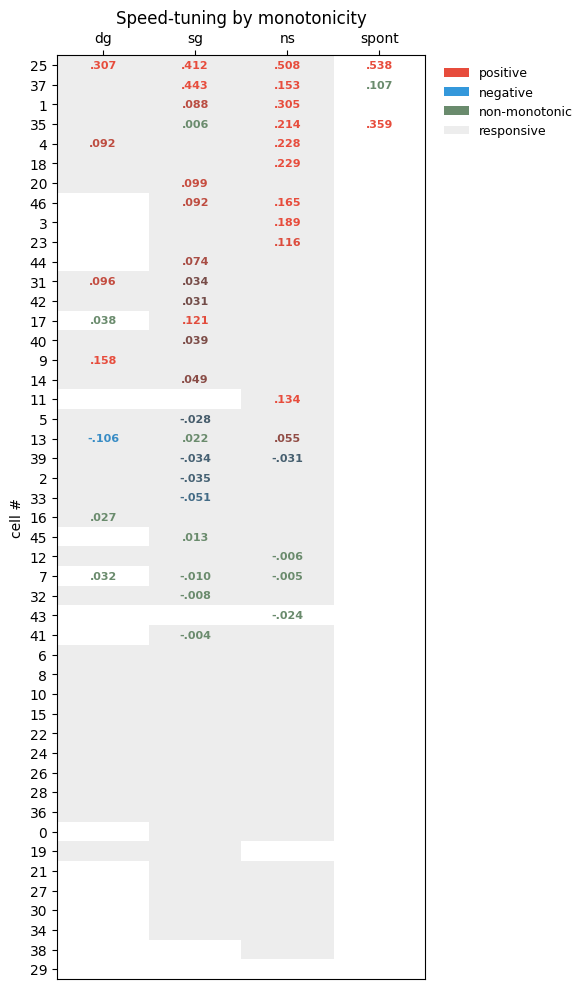

In [9]:
df = pd.read_csv("data/neurons_metadata.csv", index_col=0)
p_stim = df[[f'p_{stim}' for stim in SHORT_STIM[:-1]]].values
print(p_stim.shape)
masking = p_stim < 0.05
np.sum(masking, axis=0)

responsive = {stim: masking[:, i].T for (i, stim) in enumerate(SHORT_STIM[:-1])}

fig = plot_monotonicity_grid(tunings, responsive)
plt.savefig('doc/figures/tuning_of_neurons.png')
plt.show()

## Specific neurons

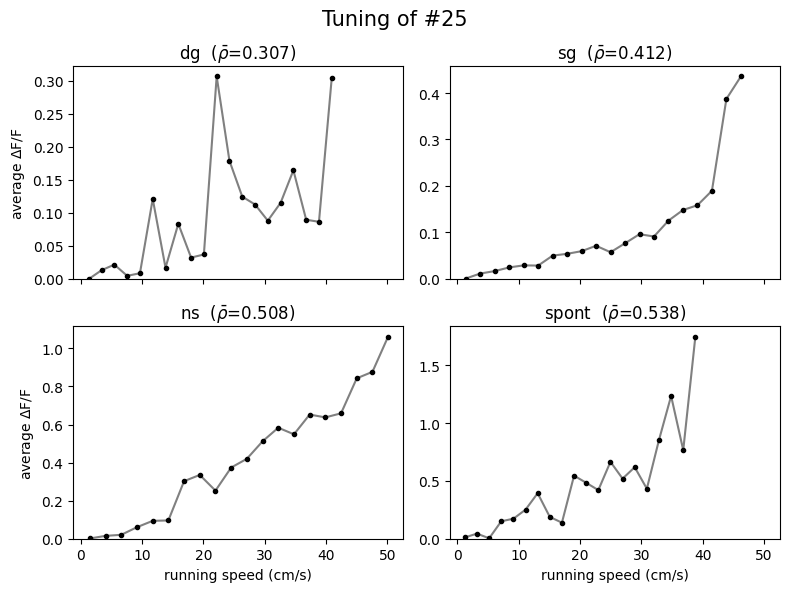

In [27]:
fig = plot_tuning_curves_grid(tunings, cells=[25], labels=SHORT_STIM, show_rho=True)
plt.suptitle("Tuning of #25", fontsize=15)
plt.show()

---

## Binary conditions

Significantly tuned neurons: #15 
 [ 1  3  4  7 11 13 17 18 25 33 35 37 39 42 46]
positive tuned neurons: #11 
 [ 1  3  4 11 13 17 25 35 37 42 46]
[0.118 0.069 0.025 0.05  0.034 0.035 0.44  0.095 0.315 0.028 0.09 ]
negative tuned neurons: #3 
 [ 7 33 39]
[-0.024 -0.023 -0.061]
non-monotonic tuned neurons: #1 
 [18]
[0.008]


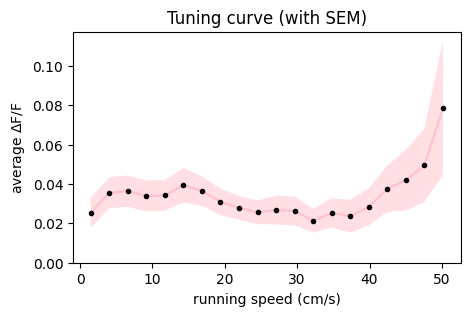

In [10]:
st_stimuli.print_tuned_cells()

ax = st_stimuli.plot_tuning_curve(semcolor='pink')
ax.set_ylim(0)
# ax.set_xscale('log')
ax.set_title("Tuning curve (with SEM)")
plt.show()

Significantly tuned neurons: #3 
 [25 35 37]
positive tuned neurons: #2 
 [25 35]
[0.538 0.359]
negative tuned neurons: #0 
 []
[]
non-monotonic tuned neurons: #1 
 [37]
[0.107]


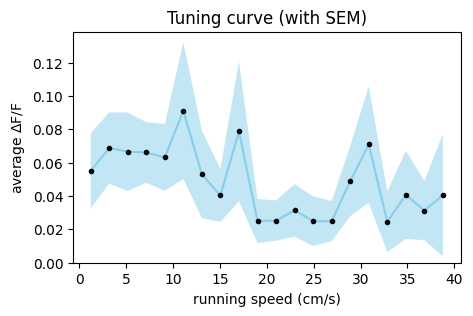

In [11]:
tunings['spont'].print_tuned_cells()

ax = tunings['spont'].plot_tuning_curve(semcolor='skyblue')
ax.set_ylim(0)
# ax.set_xscale('log')
ax.set_title("Tuning curve (with SEM)")
plt.show()

<Axes: ylabel='# significant tuned neurons'>

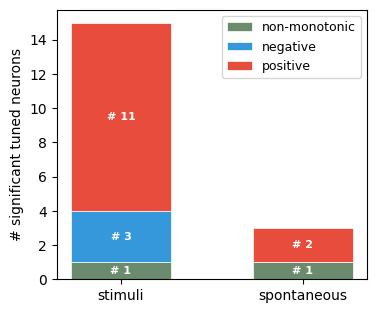

In [12]:
plot_monotonicity_stacked_bar({'stimuli': st_stimuli, 'spontaneous': tunings['spont']}, figsize=(4,3.5))  

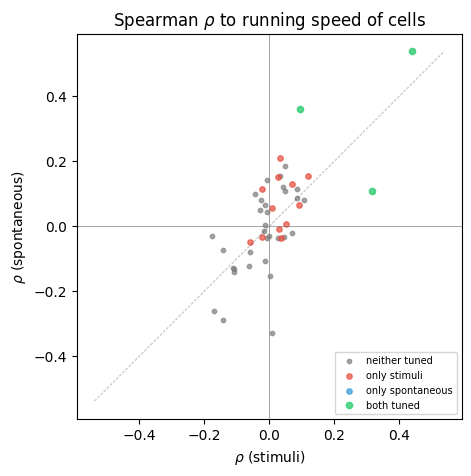

In [13]:
ax = plot_rho_pairwise_scatter(st_stimuli, tunings['spont'], 'stimuli', 'spontaneous')